## Многофакторный анализ с доверительными интервалами

Этот блок:
- читает **несколько detail CSV** (включая большие, чанками);
- агрегирует метрики по комбинациям факторов из конфигурации;
- строит **древовидный график** по каждой метрике;
- строит отдельный график доверительных интервалов.

Для `hit@k` используется **Beta-подход (Jeffreys posterior)**, как для биномиальной метрики.

In [1]:
import os
from pathlib import Path
from typing import Any, Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.stats import beta as scipy_beta
from scipy.stats import norm as scipy_norm


Разбираемся с путями до таблицами с экспериментами 

In [2]:
def _parse_paths(raw: str) -> List[str]:
    text = str(raw or '')
    for ch in [';', '\n', '\t']:
        text = text.replace(ch, ',')
    return [p.strip() for p in text.split(',') if p.strip()]


def _resolve_existing_paths(paths: Iterable[str]) -> List[str]:
    out: List[str] = []
    for p in paths:
        pp = Path(str(p))
        if pp.exists() and pp.is_file():
            out.append(str(pp))
        else:
            print(f'[WARN] detail file not found: {pp}')
    return out


Либо из env либо массив

In [3]:
DETAIL_PATHS = _resolve_existing_paths(_parse_paths(os.getenv('QDRANT_DETAIL_PATHS', '')))

# Можно задать вручную, если env-переменная пустая.
DETAIL_PATHS = [
    'review_outputs/qdrant_retrieval_detail_20260328_192829.csv',
    'review_outputs/qdrant_retrieval_detail_20260329_080222.csv',
    'review_outputs/qdrant_retrieval_detail_20260329_090215.csv',
]

Надо разобраться с порядком факторов

In [4]:
def _factor_order_from_config(config: Dict[str, Any], fallback: List[str]) -> List[str]:
    if not config:
        return fallback

    factor_order: List[str] = []
    for k in config.keys():
        if k in {'encoding_budget', 'top_k', 'rerank_k'}:
            factor_order.append(k)
            continue
        if isinstance(config[k], list) or (isinstance(config[k], dict) and 'depends_on' in config[k]):
            factor_order.append(k)

    for col in fallback:
        if col not in factor_order:
            factor_order.append(col)
    return factor_order

In [5]:
if not DETAIL_PATHS:
    print('[WARN] DETAIL_PATHS пуст. Укажите QDRANT_DETAIL_PATHS или список вручную.')

METRICS = ['hit@k', 'mrr@k', 'recall_support_rows@k']

FACTOR_COLUMNS = [
    'indexing',
    'retrieval_strategy',
    'serialization',
    'chunking',
    'query_expansion',
    'encoding_budget',
    'top_k',
    'rerank_k',
]

FACTOR_ORDER = _factor_order_from_config(
    stage1_qdrant_config if 'stage1_qdrant_config' in globals() else {},
    fallback=FACTOR_COLUMNS,
)

Агрегация метрик и расчет доверительных интервалов

In [6]:
class BootstrapCIModel:
    """Базовая модель CI: bootstrap для среднего значения метрики."""

    def __init__(self, alpha: float = 0.05, bootstrap_samples: int = 1500):
        self.alpha = float(alpha)
        self.bootstrap_samples = int(bootstrap_samples)

    @property
    def name(self) -> str:
        return 'bootstrap'

    def estimate(
        self,
        n: int,
        sum_v: float,
        sumsq_v: float,
        samples: List[float],
        rng: np.random.Generator,
    ) -> Tuple[float, float, float, str]:
        _ = n
        _ = sum_v
        _ = sumsq_v

        arr = np.asarray(samples, dtype=float)
        arr = arr[np.isfinite(arr)]

        if arr.size < 20:
            # fallback: normal mean CI when bootstrap sample слишком маленький
            mean = float(arr.mean()) if arr.size > 0 else np.nan
            if arr.size <= 1:
                return mean, mean, mean, 'bootstrap_fallback_degenerate'

            var = float(arr.var(ddof=1))
            se = np.sqrt(var / arr.size)
            z = float(scipy_norm.ppf(1.0 - self.alpha / 2.0))
            lo = max(0.0, mean - z * se)
            hi = min(1.0, mean + z * se)
            return mean, lo, hi, 'bootstrap_fallback_normal'

        idx = rng.integers(0, arr.size, size=(self.bootstrap_samples, arr.size))
        boots = arr[idx].mean(axis=1)
        mean = float(arr.mean())
        lo = float(np.quantile(boots, self.alpha / 2.0))
        hi = float(np.quantile(boots, 1.0 - self.alpha / 2.0))
        lo = max(0.0, lo)
        hi = min(1.0, hi)
        return mean, lo, hi, self.name


class HitBetaCIModel(BootstrapCIModel):
    """Наследник для hit@k: Beta Jeffreys вместо bootstrap."""

    @property
    def name(self) -> str:
        return 'beta_jeffreys'

    def estimate(
        self,
        n: int,
        sum_v: float,
        sumsq_v: float,
        samples: List[float],
        rng: np.random.Generator,
    ) -> Tuple[float, float, float, str]:
        _ = sumsq_v
        _ = samples
        _ = rng

        if n <= 0:
            return np.nan, np.nan, np.nan, self.name

        s = int(round(float(sum_v)))
        s = min(max(s, 0), int(n))
        mean = s / n

        a = s + 0.5
        b = (n - s) + 0.5
        lo = float(scipy_beta.ppf(self.alpha / 2.0, a, b))
        hi = float(scipy_beta.ppf(1.0 - self.alpha / 2.0, a, b))
        return mean, lo, hi, self.name


def _new_metric_state() -> Dict[str, Any]:
    return {
        'n': 0,
        'sum_v': 0.0,
        'sumsq_v': 0.0,
        'samples': [],
    }


def _update_metric_state(state: Dict[str, Any], values: np.ndarray, rng: np.random.Generator, reservoir_size: int) -> None:
    if values.size == 0:
        return

    state['n'] += int(values.size)
    state['sum_v'] += float(values.sum())
    state['sumsq_v'] += float(np.square(values).sum())

    samples: List[float] = state['samples']
    n_total = int(state['n'])
    for i, v in enumerate(values):
        if len(samples) < reservoir_size:
            samples.append(float(v))
        else:
            j = int(rng.integers(0, n_total - values.size + i + 1))
            if j < reservoir_size:
                samples[j] = float(v)

In [7]:
def aggregate_detail_stats_chunked(
    detail_paths: List[str],
    factor_cols: List[str],
    metrics: List[str],
    metric_ci_models: Dict[str, BootstrapCIModel],
    chunksize: int = 250_000,
    reservoir_size: int = 2000,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Потоковая агрегация detail CSV по комбинациям факторов.
    CI вычисляются через модель метрики (база bootstrap + наследник для hit).
    """
    if not detail_paths:
        raise ValueError('No detail CSV paths provided')

    missing_models = [m for m in metrics if m not in metric_ci_models]
    if missing_models:
        raise ValueError(f'Missing CI model for metrics: {missing_models}')

    needed_cols = list(dict.fromkeys(factor_cols + metrics))
    rng = np.random.default_rng(random_state)

    agg: Dict[Tuple[Any, ...], Dict[str, Dict[str, Any]]] = {}

    for path in detail_paths:
        print(f'[INFO] Reading: {path}')
        for chunk in pd.read_csv(
            path,
            usecols=lambda c: c in needed_cols,
            chunksize=chunksize,
            low_memory=True,
        ):
            missing = [c for c in needed_cols if c not in chunk.columns]
            if missing:
                raise ValueError(f'{path}: missing columns {missing}')

            for metric in metrics:
                vals = pd.to_numeric(chunk[metric], errors='coerce').to_numpy(dtype=float)
                valid = np.isfinite(vals)
                if not valid.any():
                    continue

                tmp = chunk.loc[valid, factor_cols].copy()
                tmp['_v'] = vals[valid]

                for key, sub in tmp.groupby(factor_cols, dropna=False, observed=True):
                    key_tuple = key if isinstance(key, tuple) else (key,)
                    row_key = tuple(str(x) for x in key_tuple)

                    if row_key not in agg:
                        agg[row_key] = {}
                    if metric not in agg[row_key]:
                        agg[row_key][metric] = _new_metric_state()

                    _update_metric_state(
                        agg[row_key][metric],
                        sub['_v'].to_numpy(dtype=float),
                        rng=rng,
                        reservoir_size=reservoir_size,
                    )

    rows: List[Dict[str, Any]] = []
    for combo_key, metric_states in agg.items():
        base = {c: combo_key[i] for i, c in enumerate(factor_cols)}

        for metric in metrics:
            st = metric_states.get(metric)
            if st is None or int(st['n']) <= 0:
                continue

            model = metric_ci_models[metric]
            mean, lo, hi, ci_method = model.estimate(
                n=int(st['n']),
                sum_v=float(st['sum_v']),
                sumsq_v=float(st['sumsq_v']),
                samples=list(st['samples']),
                rng=rng,
            )

            rows.append({
                **base,
                'metric': metric,
                'n': int(st['n']),
                'sum_v': float(st['sum_v']),
                'sumsq_v': float(st['sumsq_v']),
                'sample_values': list(st['samples']),
                'mean': float(mean),
                'ci_low': float(lo),
                'ci_high': float(hi),
                'ci_width': float(hi - lo),
                'ci_method': ci_method,
            })

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values(['metric', 'mean', 'n'], ascending=[True, False, False]).reset_index(drop=True)
    return out

In [8]:
METRIC_CI_MODELS: Dict[str, BootstrapCIModel] = {
    'hit@k': HitBetaCIModel(alpha=0.05),
    'mrr@k': BootstrapCIModel(alpha=0.05, bootstrap_samples=1500),
    'recall_support_rows@k': BootstrapCIModel(alpha=0.05, bootstrap_samples=1500),
}

stats_df = aggregate_detail_stats_chunked(
    detail_paths=DETAIL_PATHS,
    factor_cols=FACTOR_ORDER,
    metrics=METRICS,
    metric_ci_models=METRIC_CI_MODELS,
    chunksize=250_000,
    reservoir_size=2000,
    random_state=42,
)

print(f'Aggregated leaf rows: {len(stats_df)}')
display(stats_df.head(20))

[INFO] Reading: review_outputs/qdrant_retrieval_detail_20260328_192829.csv
[INFO] Reading: review_outputs/qdrant_retrieval_detail_20260329_080222.csv
[INFO] Reading: review_outputs/qdrant_retrieval_detail_20260329_090215.csv
Aggregated leaf rows: 432


,indexing,retrieval_strategy,serialization,chunking,query_expansion,encoding_budget,top_k,rerank_k,metric,n,sum_v,sumsq_v,sample_values,mean,ci_low,ci_high,ci_width,ci_method
0,hybrid,rrf,json,table_level,llm_generated,512,10,50,hit@k,28085,15485.0,15485.0,"[0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...",0.551362,0.545540,0.557173,0.011633,beta_jeffreys
1,hybrid,rrf,sentence,table_level,llm_generated,512,10,50,hit@k,28085,15389.0,15389.0,"[0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, ...",0.547944,0.542118,0.553759,0.011641,beta_jeffreys
2,dense_only,rrf,json,table_level,llm_generated,512,10,50,hit@k,28085,15310.0,15310.0,"[1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.545131,0.539303,0.550950,0.011647,beta_jeffreys
3,hybrid,rrf,sentence,table_level,none,512,10,50,hit@k,10488,5708.0,5708.0,"[0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, ...",0.544241,0.534698,0.553759,0.019061,beta_jeffreys
4,hybrid,rrf,json,table_level,none,512,10,50,hit@k,10488,5678.0,5678.0,"[1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, ...",0.541381,0.531834,0.550904,0.019070,beta_jeffreys
5,hybrid,rrf,markdown,table_level,none,512,10,50,hit@k,10488,5646.0,5646.0,"[1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, ...",0.538330,0.528779,0.547859,0.019080,beta_jeffreys
6,dense_only,rrf,markdown,table_level,none,512,10,50,hit@k,10488,5625.0,5625.0,"[1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",0.536327,0.526774,0.545860,0.019085,beta_jeffreys
7,hybrid,rrf,markdown,table_level,llm_generated,512,10,50,hit@k,28085,15040.0,15040.0,"[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",0.535517,0.529681,0.541346,0.011665,beta_jeffreys
8,dense_only,rrf,sentence,table_level,none,512,10,50,hit@k,10488,5598.0,5598.0,"[0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, ...",0.533753,0.524197,0.543290,0.019092,beta_jeffreys
9,dense_only,rrf,json,table_level,none,512,10,50,hit@k,10488,5586.0,5586.0,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, ...",0.532609,0.523052,0.542147,0.019095,beta_jeffreys


Построение дерева

In [9]:
def build_factor_tree_stats(
    leaf_stats_df: pd.DataFrame,
    metric: str,
    factor_order: List[str],
    metric_ci_models: Dict[str, BootstrapCIModel],
    max_leaf_nodes: int = 200,
    random_state: int = 42,
    reservoir_size: int = 2000,
) -> pd.DataFrame:
    """
    Строит статистику узлов дерева для каждого уровня факторов.
    CI вычисляются через модель metric_ci_models[metric].
    """
    d = leaf_stats_df[leaf_stats_df['metric'] == metric].copy()
    if d.empty:
        return pd.DataFrame()

    if metric not in metric_ci_models:
        raise ValueError(f'No CI model for metric: {metric}')

    factor_cols = [c for c in factor_order if c in d.columns]
    if not factor_cols:
        return pd.DataFrame()

    d = d.sort_values(['n', 'mean'], ascending=[False, False]).head(max_leaf_nodes).copy()
    model = metric_ci_models[metric]
    rng = np.random.default_rng(random_state)

    rows: List[Dict[str, Any]] = []

    for depth in range(1, len(factor_cols) + 1):
        prefix_cols = factor_cols[:depth]

        for key, sub in d.groupby(prefix_cols, dropna=False, observed=True):
            key_tuple = key if isinstance(key, tuple) else (key,)
            prefix_vals = tuple(str(x) for x in key_tuple)

            n = int(sub['n'].sum())
            sum_v = float(sub['sum_v'].sum())
            sumsq_v = float(sub['sumsq_v'].sum())

            pooled: List[float] = []
            if 'sample_values' in sub.columns:
                for arr in sub['sample_values'].tolist():
                    if isinstance(arr, list) and arr:
                        pooled.extend(float(x) for x in arr)

            if pooled and len(pooled) > reservoir_size:
                idx = rng.choice(len(pooled), size=reservoir_size, replace=False)
                pooled = [pooled[i] for i in idx]

            mean, lo, hi, ci_method = model.estimate(
                n=n,
                sum_v=sum_v,
                sumsq_v=sumsq_v,
                samples=pooled,
                rng=rng,
            )

            parent_vals = prefix_vals[:-1]
            rows.append({
                'metric': metric,
                'depth': depth,
                'factor_name': factor_cols[depth - 1],
                'factor_value': prefix_vals[-1],
                'node_key': ' -> '.join(prefix_vals),
                'parent_key': ' -> '.join(parent_vals) if parent_vals else None,
                'n': n,
                'sum_v': sum_v,
                'sumsq_v': sumsq_v,
                'mean': float(mean),
                'ci_low': float(lo),
                'ci_high': float(hi),
                'ci_method': ci_method,
            })

    return pd.DataFrame(rows)

In [10]:
def plot_metric_factor_tree(
    leaf_stats_df: pd.DataFrame,
    metric: str,
    factor_order: List[str],
    metric_ci_models: Dict[str, BootstrapCIModel],
    max_leaf_nodes: int = 200,
):
    """
    Граф дерева:
    - ось X: уровни факторов (depth)
    - ось Y: значение метрики
    - ребра: parent -> child
    - вертикальные error bars: доверительные интервалы
    """
    nodes = build_factor_tree_stats(
        leaf_stats_df=leaf_stats_df,
        metric=metric,
        factor_order=factor_order,
        metric_ci_models=metric_ci_models,
        max_leaf_nodes=max_leaf_nodes,
        random_state=42,
        reservoir_size=2000,
    )
    if nodes.empty:
        print(f'[INFO] No rows for metric={metric}')
        return None

    node_map = {r['node_key']: r for _, r in nodes.iterrows()}

    edge_x: List[float] = []
    edge_y: List[float] = []
    for _, r in nodes.iterrows():
        pk = r['parent_key']
        if pk is None or pk not in node_map:
            continue
        pr = node_map[pk]
        edge_x.extend([float(pr['depth']), float(r['depth']), None])
        edge_y.extend([float(pr['mean']), float(r['mean']), None])

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=edge_x,
            y=edge_y,
            mode='lines',
            line=dict(color='rgba(90,90,90,0.35)', width=1),
            hoverinfo='skip',
            showlegend=False,
        )
    )

    size = 8 + 20 * (nodes['n'] / nodes['n'].max()) ** 0.35
    label = nodes['factor_name'] + '=' + nodes['factor_value']

    fig.add_trace(
        go.Scatter(
            x=nodes['depth'],
            y=nodes['mean'],
            mode='markers',
            marker=dict(
                size=size,
                color=nodes['depth'],
                colorscale='Cividis',
                line=dict(width=0.5, color='rgba(40,40,40,0.8)'),
            ),
            error_y=dict(
                type='data',
                symmetric=False,
                array=(nodes['ci_high'] - nodes['mean']).clip(lower=0.0),
                arrayminus=(nodes['mean'] - nodes['ci_low']).clip(lower=0.0),
                thickness=1,
                width=2,
            ),
            text=label,
            customdata=np.stack([nodes['node_key'], nodes['n'], nodes['ci_low'], nodes['ci_high'], nodes['ci_method']], axis=1),
            hovertemplate=(
                '%{customdata[0]}<br>'
                'mean=%{y:.4f}<br>'
                'n=%{customdata[1]}<br>'
                'CI=[%{customdata[2]:.4f}, %{customdata[3]:.4f}]<br>'
                'method=%{customdata[4]}<extra></extra>'
            ),
            showlegend=False,
        )
    )

    max_depth = int(nodes['depth'].max())
    tick_vals = list(range(1, max_depth + 1))
    tick_text = [factor_order[i - 1] if i - 1 < len(factor_order) else f'level_{i}' for i in tick_vals]

    fig.update_layout(
        title=f'{metric}: factor tree with confidence intervals',
        xaxis=dict(title='factors (tree levels)', tickmode='array', tickvals=tick_vals, ticktext=tick_text),
        yaxis=dict(title=metric, range=[-0.02, 1.02]),
        height=700,
    )

    return fig

In [11]:
for metric_name in METRICS:
    fig_tree = plot_metric_factor_tree(
        leaf_stats_df=stats_df,
        metric=metric_name,
        factor_order=FACTOR_ORDER,
        metric_ci_models=METRIC_CI_MODELS,
        max_leaf_nodes=250,
    )
    if fig_tree is not None:
        fig_tree.show()

## Альтернативная визуализация: метрика vs время по типу индексирования

- 3 отдельных графика: `sparse`, `dense`, `hybrid`
- X: время (`runtime_sec`)
- Y: выбранная метрика (`METRIC_Y`)
- Цвет: сериализация (`markdown/json/sentence`)
- Форма и стиль: чанкинг
- Доверительный интервал: эллипс вокруг точки (95% CI по повторным прогонам)

[INFO] Reading: review_outputs/qdrant_retrieval_detail_20260328_192829.csv
[INFO] Reading: review_outputs/qdrant_retrieval_detail_20260329_080222.csv
[INFO] Reading: review_outputs/qdrant_retrieval_detail_20260329_090215.csv


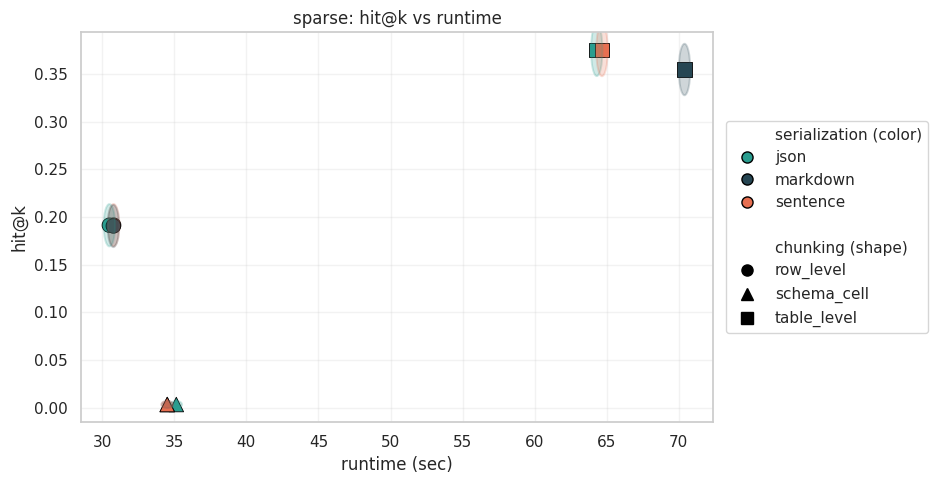

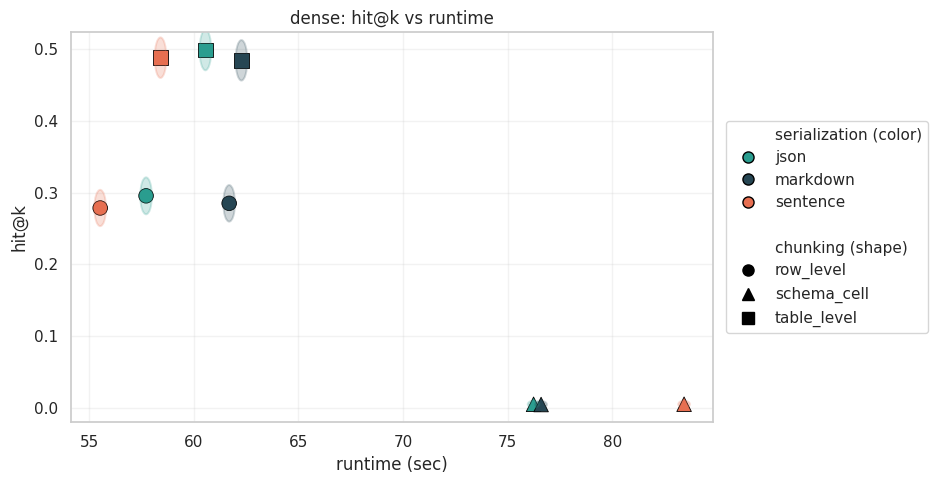

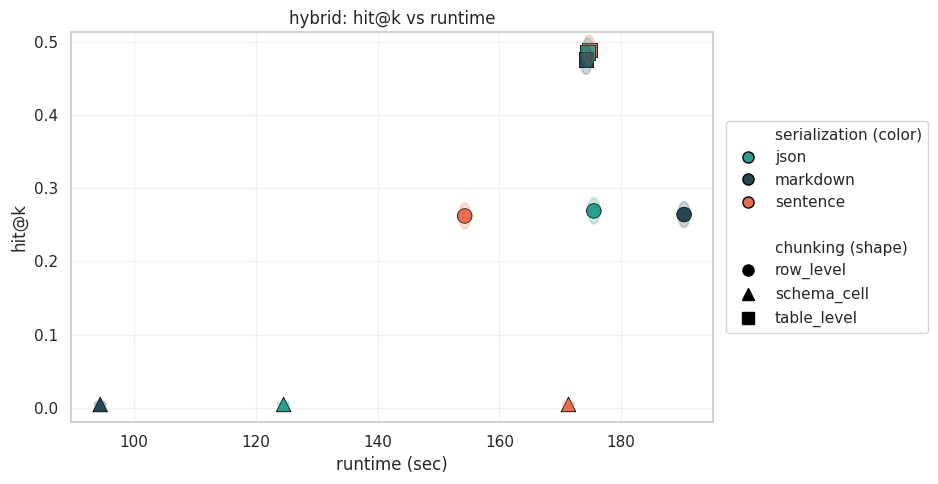

In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

METRIC_Y = 'hit@k'  # например: 'hit@k', 'mrr@k', 'recall_support_rows@k'

# Новая более контрастная тема (без дефолтной matplotlib-палитры)
COLOR_BY_SERIALIZATION = {
    'markdown': '#264653',  # deep teal
    'json': '#2A9D8F',      # aqua green
    'sentence': '#E76F51',  # coral
}
MARKER_BY_CHUNKING = {'row_level': 'o', 'table_level': 's', 'schema_cell': '^'}
PLOT_FACTORS = ['indexing', 'serialization', 'chunking']

# Настройки видимости CI (данные не меняются, меняется только отображение)
CI_VIS_SCALE_X = 8.0
CI_VIS_SCALE_Y = 8.0
MIN_CI_FRAC_X = 0.02  # минимум 2% ширины диапазона X
MIN_CI_FRAC_Y = 0.02  # минимум 2% высоты диапазона Y
ELLIPSE_ALPHA = 0.22

# Модель CI для метрики: используем существующие классы/конфиг
metric_ci_models = globals().get('METRIC_CI_MODELS', {})
if METRIC_Y in metric_ci_models:
    metric_model = metric_ci_models[METRIC_Y]
elif METRIC_Y == 'hit@k' and 'HitBetaCIModel' in globals():
    metric_model = HitBetaCIModel(alpha=0.05)
else:
    metric_model = BootstrapCIModel(alpha=0.05, bootstrap_samples=1500)

time_model = BootstrapCIModel(alpha=0.05, bootstrap_samples=1500)
rng = np.random.default_rng(42)

# 1) Метрика и CI из DETAIL (по уже существующему подходу агрегации)
if 'DETAIL_PATHS' in globals() and DETAIL_PATHS:
    detail_paths = [Path(p) for p in DETAIL_PATHS]
else:
    detail_paths = sorted(Path('review_outputs').glob('qdrant_retrieval_detail_*.csv'))

if 'aggregate_detail_stats_chunked' in globals():
    metric_stats = aggregate_detail_stats_chunked(
        detail_paths=[str(p) for p in detail_paths],
        factor_cols=PLOT_FACTORS,
        metrics=[METRIC_Y],
        metric_ci_models={METRIC_Y: metric_model},
        chunksize=250_000,
        reservoir_size=2000,
        random_state=42,
    )
else:
    rows = []
    for p in detail_paths:
        d = pd.read_csv(p, usecols=lambda c: c in set(PLOT_FACTORS + [METRIC_Y]))
        d[METRIC_Y] = pd.to_numeric(d[METRIC_Y], errors='coerce')
        d = d[np.isfinite(d[METRIC_Y])]
        if not d.empty:
            rows.append(d)
    all_d = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=PLOT_FACTORS + [METRIC_Y])

    out = []
    for key, sub in all_d.groupby(PLOT_FACTORS, dropna=False, observed=True):
        y = sub[METRIC_Y].to_numpy(dtype=float)
        y_mean, y_lo, y_hi, y_method = metric_model.estimate(
            n=int(y.size),
            sum_v=float(y.sum()),
            sumsq_v=float(np.square(y).sum()),
            samples=y.tolist(),
            rng=rng,
        )
        key = key if isinstance(key, tuple) else (key,)
        out.append({
            **{PLOT_FACTORS[i]: key[i] for i in range(len(PLOT_FACTORS))},
            'metric': METRIC_Y,
            'mean': y_mean,
            'ci_low': y_lo,
            'ci_high': y_hi,
            'ci_method': y_method,
        })
    metric_stats = pd.DataFrame(out)

metric_stats = metric_stats[metric_stats['metric'] == METRIC_Y].copy()
metric_stats['indexing'] = metric_stats['indexing'].replace({'sparse_only': 'sparse', 'dense_only': 'dense'})
metric_stats = metric_stats.rename(columns={'mean': 'y_mean', 'ci_low': 'y_lo', 'ci_high': 'y_hi'})

# 2) Runtime и CI из SUMMARY (detail не содержит runtime_sec)
summary_paths = ['review_outputs/summary_28_19_29_08_29_09.csv']
sum_df = pd.concat([pd.read_csv(p) for p in summary_paths], ignore_index=True)
sum_df = sum_df[sum_df['status'].eq('ok')].copy()
sum_df['runtime_sec'] = pd.to_numeric(sum_df['runtime_sec'], errors='coerce')
sum_df = sum_df[np.isfinite(sum_df['runtime_sec'])]
sum_df['indexing'] = sum_df['indexing'].replace({'sparse_only': 'sparse', 'dense_only': 'dense'})

time_rows = []
for key, sub in sum_df.groupby(PLOT_FACTORS, dropna=False, observed=True):
    x = sub['runtime_sec'].to_numpy(dtype=float)
    x_mean, x_lo, x_hi, _ = time_model.estimate(
        n=int(x.size),
        sum_v=float(x.sum()),
        sumsq_v=float(np.square(x).sum()),
        samples=x.tolist(),
        rng=rng,
    )
    key = key if isinstance(key, tuple) else (key,)
    time_rows.append({
        **{PLOT_FACTORS[i]: key[i] for i in range(len(PLOT_FACTORS))},
        'x_mean': float(x_mean),
        'x_lo': float(x_lo),
        'x_hi': float(x_hi),
    })

time_stats = pd.DataFrame(time_rows)

plot_df = metric_stats.merge(time_stats, on=PLOT_FACTORS, how='inner')

sns.set_theme(style='whitegrid')
for idx in ['sparse', 'dense', 'hybrid']:
    part = plot_df[plot_df['indexing'] == idx].copy()
    if part.empty:
        continue

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.scatterplot(
        data=part,
        x='x_mean',
        y='y_mean',
        hue='serialization',
        style='chunking',
        palette=COLOR_BY_SERIALIZATION,
        markers=MARKER_BY_CHUNKING,
        s=110,
        edgecolor='black',
        linewidth=0.6,
        legend=False,
        ax=ax,
    )

    x_span = float(part['x_mean'].max() - part['x_mean'].min()) if len(part) > 1 else 1.0
    y_span = float(part['y_mean'].max() - part['y_mean'].min()) if len(part) > 1 else 1.0
    x_min_vis = max(x_span * MIN_CI_FRAC_X, 1e-6)
    y_min_vis = max(y_span * MIN_CI_FRAC_Y, 1e-6)

    for _, r in part.iterrows():
        color = COLOR_BY_SERIALIZATION.get(r['serialization'], '#777777')

        width_raw = max(float(r['x_hi'] - r['x_lo']), 1e-9)
        height_raw = max(float(r['y_hi'] - r['y_lo']), 1e-9)
        width_vis = max(width_raw * CI_VIS_SCALE_X, x_min_vis)
        height_vis = max(height_raw * CI_VIS_SCALE_Y, y_min_vis)

        ax.add_patch(Ellipse(
            xy=(float(r['x_mean']), float(r['y_mean'])),
            width=width_vis,
            height=height_vis,
            facecolor=color,
            edgecolor=color,
            linestyle='solid',
            linewidth=1.4,
            alpha=ELLIPSE_ALPHA,
            zorder=1,
        ))

    ax.set_title(f'{idx}: {METRIC_Y} vs runtime')
    ax.set_xlabel('runtime (sec)')
    ax.set_ylabel(METRIC_Y)
    ax.grid(alpha=0.25)

    ser_legend = [
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor=COLOR_BY_SERIALIZATION[s],
               markeredgecolor='black', color='none', label=s, markersize=8)
        for s in sorted(part['serialization'].dropna().unique()) if s in COLOR_BY_SERIALIZATION
    ]
    chunk_legend = [
        Line2D([0], [0], marker=MARKER_BY_CHUNKING.get(k, 'o'), linestyle='None',
               markerfacecolor='black', markeredgecolor='black', color='none', label=k, markersize=8)
        for k in sorted(part['chunking'].dropna().unique())
    ]

    combined_handles = []
    if ser_legend:
        combined_handles.append(Line2D([0], [0], linestyle='None', color='none', label='serialization (color)'))
        combined_handles.extend(ser_legend)
    if ser_legend and chunk_legend:
        combined_handles.append(Line2D([0], [0], linestyle='None', color='none', label=''))
    if chunk_legend:
        combined_handles.append(Line2D([0], [0], linestyle='None', color='none', label='chunking (shape)'))
        combined_handles.extend(chunk_legend)

    if combined_handles:
        ax.legend(
            handles=combined_handles,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
            frameon=True,
        )

    plt.tight_layout(rect=[0.0, 0.0, 0.80, 1.0])
    plt.show()

## GEE

In [2]:
# GEE: влияние каждого фактора относительно baseline
# Baseline адаптируется под структуру основного эксперимента
# Если statsmodels не установлен в ядре, раскомментируйте:
# %pip install -q statsmodels

from pathlib import Path
import re
from typing import Dict

import statsmodels.api as sm
import statsmodels.formula.api as smf
# from patsy.builtins import Q, Treatment

GEE_RESPONSE_COL = 'hit@k'
GEE_GROUP_COL = 'qid'

# Для GEE используем составной фактор: hybrid раскладывается по retrieval_strategy.
# chunking также входит в indexing_combo, чтобы не дублировать сигнал отдельным фактором.
GEE_FACTOR_COLS = [
    'indexing_combo',
    'serialization',
    'query_expansion',
    'top_k',
]


In [9]:
def _normalize_gee_value(v):
    if pd.isna(v):
        return 'missing'
    if isinstance(v, (np.integer, int)):
        return str(int(v))
    if isinstance(v, (np.floating, float)):
        fv = float(v)
        return str(int(fv)) if fv.is_integer() else str(fv)
    return str(v).strip()



def _build_gee_indexing_combo(indexing_value, retrieval_strategy_value, chunking_value):
    indexing_norm = _normalize_gee_value(indexing_value)
    retrieval_norm = _normalize_gee_value(retrieval_strategy_value)
    chunking_norm = _normalize_gee_value(chunking_value)

    if indexing_norm.lower() == 'hybrid' and retrieval_norm.lower() not in {'', 'missing'}:
        return f'{indexing_norm}__{retrieval_norm}__{chunking_norm}'

    return f'{indexing_norm}__{chunking_norm}'



def load_hit_gee_dataframe(
    detail_paths,
    baseline_detail_paths=None,
    baseline_factor_map: Dict[str, str] = None,
    response_col=GEE_RESPONSE_COL,
    group_col=GEE_GROUP_COL,
    factor_cols=GEE_FACTOR_COLS,
    chunksize=250_000,
):
    """
    Загружает detail CSV и вычисляет reference значения факторов из baseline.
    Если baseline не содержит явных factor-колонок, они будут заполнены из baseline_factor_map.
    Returns: (df, baseline_refs_dict)
    """
    baseline_factor_map = baseline_factor_map or {}
    factor_cols = list(factor_cols)

    # retrieval_strategy и chunking нужны только как источники для indexing_combo.
    aux_cols = ['retrieval_strategy', 'indexing', 'chunking']
    usecols_main = list(dict.fromkeys([group_col, response_col] + factor_cols + aux_cols))
    usecols_baseline = list(dict.fromkeys([group_col, response_col] + factor_cols + aux_cols))
    frames_main = []
    frames_baseline = []

    for path in detail_paths:
        print(f'[INFO] Reading for GEE (main): {path}')
        for chunk in pd.read_csv(
            path,
            usecols=lambda c: c in usecols_main,
            chunksize=chunksize,
            low_memory=True,
        ):
            if response_col not in chunk.columns or group_col not in chunk.columns:
                continue

            chunk = chunk.copy()
            chunk[response_col] = pd.to_numeric(chunk[response_col], errors='coerce', downcast='integer')
            chunk = chunk[np.isfinite(chunk[response_col])]
            chunk = chunk.dropna(subset=[group_col])
            if chunk.empty:
                continue

            chunk[group_col] = chunk[group_col].astype(str)
            for col in factor_cols:
                if col not in chunk.columns:
                    chunk[col] = 'missing'
                else:
                    chunk[col] = chunk[col].map(_normalize_gee_value)

            if 'retrieval_strategy' not in chunk.columns:
                chunk['retrieval_strategy'] = 'missing'
            else:
                chunk['retrieval_strategy'] = chunk['retrieval_strategy'].map(_normalize_gee_value)

            chunk['indexing_combo'] = [
                _build_gee_indexing_combo(ix, rs, ch)
                for ix, rs, ch in zip(chunk['indexing'], chunk['retrieval_strategy'], chunk['chunking'])
            ]

            frames_main.append(chunk[[group_col, response_col] + factor_cols])

    baseline_detail_paths = baseline_detail_paths or []
    for path in baseline_detail_paths:
        print(f'[INFO] Reading for GEE (baseline): {path}')
        for chunk in pd.read_csv(
            path,
            usecols=lambda c: c in usecols_baseline,
            chunksize=chunksize,
            low_memory=True,
        ):
            if response_col not in chunk.columns or group_col not in chunk.columns:
                continue

            chunk = chunk.copy()
            chunk[response_col] = pd.to_numeric(chunk[response_col], errors='coerce', downcast='integer')
            chunk = chunk[np.isfinite(chunk[response_col])]
            chunk = chunk.dropna(subset=[group_col])
            if chunk.empty:
                continue

            chunk[group_col] = chunk[group_col].astype(str)
            # Заполняем/нормализуем факторные поля для baseline
            for col in factor_cols:
                if col in chunk.columns:
                    chunk[col] = chunk[col].map(_normalize_gee_value)
                else:
                    # если в baseline нет этой колонки, используем карту соответствий
                    chunk[col] = baseline_factor_map.get(col, 'baseline')

            if 'retrieval_strategy' not in chunk.columns:
                chunk['retrieval_strategy'] = 'missing'
            else:
                chunk['retrieval_strategy'] = chunk['retrieval_strategy'].map(_normalize_gee_value)

            if 'indexing' not in chunk.columns:
                chunk['indexing'] = baseline_factor_map.get('indexing', 'missing')
            
            if 'chunking' not in chunk.columns:
                chunk['chunking'] = baseline_factor_map.get('chunking', 'missing')

            chunk['indexing_combo'] = [
                _build_gee_indexing_combo(ix, rs, ch)
                for ix, rs, ch in zip(chunk['indexing'], chunk['retrieval_strategy'], chunk['chunking'])
            ]

            frames_baseline.append(chunk[[group_col, response_col] + factor_cols])

    if not frames_main:
        raise ValueError('No main rows loaded for GEE')

    df_main = pd.concat(frames_main, ignore_index=True)

    # Вычисляем reference значения для каждого фактора из baseline
    baseline_refs = {}
    if frames_baseline:
        df_baseline = pd.concat(frames_baseline, ignore_index=True)
        for col in factor_cols:
            if col in df_baseline.columns:
                most_common = df_baseline[col].value_counts().idxmax()
                baseline_refs[col] = most_common
                print(f'[INFO] Reference ({col}): {most_common}')
        df = pd.concat([df_baseline,df_main], ignore_index=True)
    else:
        df = df_main
        print('[WARN] No baseline data. Using first alphabetical value as reference.')
        for col in factor_cols:
            if col in df.columns:
                baseline_refs[col] = sorted(df[col].dropna().unique())[0]

    for col in factor_cols:
        df[col] = df[col].astype('category')

    df[response_col] = (pd.to_numeric(df[response_col], errors='coerce') > 0.5).astype(int)
    return df, baseline_refs



In [10]:
gee_detail_paths = [
    Path('review_outputs/qdrant_retrieval_detail_20260429_074422.csv'),
    Path('review_outputs/qdrant_retrieval_detail_20260429_090748.csv'),
    Path('review_outputs/qdrant_retrieval_detail_20260429_133525.csv'),
]

gee_baseline_paths = [
    Path("review_outputs/qdrant_retrieval_baseline_detail_20260420_203236.csv")
]

gee_baseline_paths = [p for p in gee_baseline_paths if p.exists()]
if not gee_baseline_paths:
    print('[WARN] Baseline detail files not found.')

# карта соответствия для baseline: заполняет отсутствующие факторы
DEFAULT_BASELINE_FACTOR_MAP = {
    'serialization': 'markdown',
    'indexing': 'dense',
    'chunking': 'recursive',
    'retrieval_strategy': 'baseline',
    'query_expansion': 'none',
    # 'encoding_budget': 'full',
    'top_k': '10',
    # 'rerank_k': '0',
}

gee_df, baseline_references = load_hit_gee_dataframe(
    detail_paths=gee_detail_paths,
    baseline_detail_paths=gee_baseline_paths,
    baseline_factor_map=DEFAULT_BASELINE_FACTOR_MAP,
)
print(f'GEE rows: {len(gee_df)}')
print(f'Baseline references: {baseline_references}')




[INFO] Reading for GEE (main): review_outputs/qdrant_retrieval_detail_20260429_074422.csv
[INFO] Reading for GEE (main): review_outputs/qdrant_retrieval_detail_20260429_090748.csv
[INFO] Reading for GEE (main): review_outputs/qdrant_retrieval_detail_20260429_133525.csv
[INFO] Reading for GEE (baseline): review_outputs/qdrant_retrieval_baseline_detail_20260420_203236.csv
[INFO] Reference (indexing_combo): dense__recursive
[INFO] Reference (serialization): markdown
[INFO] Reference (query_expansion): none
[INFO] Reference (top_k): 10
GEE rows: 1861992
Baseline references: {'indexing_combo': 'dense__recursive', 'serialization': 'markdown', 'query_expansion': 'none', 'top_k': '10'}


In [5]:
print("ТОП-5 самых больших групп:")
print(gee_df[GEE_GROUP_COL].value_counts().head(5))

ТОП-5 самых больших групп:
qid
5202296/table_3::q::4    193
3837924/table_0::q::0    193
4081084/table_1::q::5    193
1054892/table_1::q::4    193
1939832/table_9::q::5    193
Name: count, dtype: int64


In [14]:
def _gee_term_order(df, factor_cols):
    ordered = []
    for col in factor_cols:
        if col not in df.columns:
            continue
        if df[col].nunique(dropna=True) <= 1:
            print(f'[INFO] Skip constant factor: {col}')
            continue
        ordered.append(col)
    if not ordered:
        raise ValueError('No varying factor columns found for GEE')
    return ordered

def build_hit_gee_formula(
    df,
    baseline_refs,
    response_col=GEE_RESPONSE_COL,
    factor_cols=GEE_FACTOR_COLS,
):
    """Формула с отдельными факторами, каждый с reference из baseline."""
    active_cols = _gee_term_order(df, factor_cols)
    
    terms = []
    for col in active_cols:
        ref = baseline_refs.get(col)
        if ref:
            terms.append(f'C({col}, Treatment(reference="{ref}"))')
        else:
            terms.append(f'C({col})')
        # terms.append(f'C({col})')

    formula = f'Q("{response_col}") ~ ' + ' + '.join(terms)
    return formula, active_cols

def fit_hit_gee(
    df,
    baseline_refs,
    response_col=GEE_RESPONSE_COL,
    group_col=GEE_GROUP_COL,
    factor_cols=GEE_FACTOR_COLS,
    cov_struct=None,
):
    if group_col not in df.columns:
        raise ValueError(f'Grouping column not found: {group_col}')

    formula, active_cols = build_hit_gee_formula(
        df,
        baseline_refs,
        response_col=response_col,
        factor_cols=factor_cols,
    )
    print(formula)
    if cov_struct is None:
        cov_struct = sm.cov_struct.Independence()

    model = smf.gee(
        formula=formula,
        groups=df[group_col],
        data=df,
        family=sm.families.Binomial(),
        cov_struct=cov_struct,
    )
    result = model.fit()
    return model, result, formula, active_cols

    # df = df.sort_values(by=group_col).reset_index(drop=True)

    y = df[response_col].astype(float).values
    groups = df[group_col].values

# Создаем дамми-переменные вручную (аналог C(...) в формуле)
    X = pd.get_dummies(df[factor_cols], drop_first=True, dtype=float)
    X = sm.add_constant(X)

# 3. Удаляем исходный DataFrame ПЕРЕД обучением
# Это освободит место, которое раньше занимали строки и лишние колонки
    del df
    import gc
    gc.collect()
    print("start training")
# 4. Обучение
    model = sm.GEE(y, X, groups=groups, family=sm.families.Binomial(), cov_struct=cov_struct)
    result = model.fit()

    # result = model.fit(maxiter=60)
    # try:
        
    # except Exception as exc:
    #     print(f'[WARN] GEE fit failed with {type(cov_struct).__name__}: {exc}')
    #     print('[WARN] Retrying with Independence covariance structure')
    #     model = smf.gee(
    #         formula=formula,
    #         groups=df[group_col],
    #         data=df,
    #         family=sm.families.Binomial(),
    #         cov_struct=sm.cov_struct.Independence(),
    #     )
    #     result = model.fit()

    return model, result, formula, active_cols


In [15]:
gee_model, gee_result, gee_formula, gee_active_cols = fit_hit_gee(
    gee_df,
    baseline_references,
)
print('Formula:', gee_formula)
print(gee_result.summary())

Q("hit@k") ~ C(indexing_combo, Treatment(reference="dense__recursive")) + C(serialization, Treatment(reference="markdown")) + C(query_expansion, Treatment(reference="none")) + C(top_k, Treatment(reference="10"))
Formula: Q("hit@k") ~ C(indexing_combo, Treatment(reference="dense__recursive")) + C(serialization, Treatment(reference="markdown")) + C(query_expansion, Treatment(reference="none")) + C(top_k, Treatment(reference="10"))
                               GEE Regression Results                              
Dep. Variable:                  Q("hit@k")   No. Observations:              1861992
Model:                                 GEE   No. clusters:                    10488
Method:                        Generalized   Min. cluster size:                  97
                      Estimating Equations   Max. cluster size:                 193
Family:                           Binomial   Mean cluster size:               177.5
Dependence structure:         Independence   Num. iterations:  

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Создаем формулу, где chunking — предиктор
formula = 'Q("hit@k") ~ C(chunking) + C(indexing_combo) + C(serialization) + C(query_expansion) + C(top_k)'

ols = smf.ols(formula, data=gee_df).fit()

# VIF для каждого параметра
design = ols.model.exog
vif_data = pd.DataFrame({
    'variable': ols.model.exog_names,
    'VIF': [variance_inflation_factor(design, i) for i in range(design.shape[1])]
})
print(vif_data.sort_values('VIF', ascending=False))

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns


def _parse_gee_term(term):
    m_treat = re.match(
        r'^C\((?P<factor>.+?),\s*Treatment\(reference="?.+?"?\)\)\[T\.(?P<level>.+)\]$',
        term,
    )
    if m_treat:
        return m_treat.group('factor'), m_treat.group('level')

    m = re.match(r'^C\((?P<factor>.+?)\)\[T\.(?P<level>.+)\]$', term)
    if m:
        return m.group('factor'), m.group('level')
    return term, ''


def _humanize_gee_token(value):
    text = str(value).strip()
    text = text.replace('__', ' / ')
    text = text.replace('_', ' ')
    return ' '.join(text.split())


def _format_gee_label(factor, level):
    factor = str(factor)
    level = str(level)

    if factor == 'indexing_combo' and level:
        parts = level.split('__')
        if len(parts) == 3:
            indexing, strategy, chunking = parts
            return ' / '.join([
                _humanize_gee_token(indexing),
                _humanize_gee_token(strategy),
                _humanize_gee_token(chunking),
            ])
        return _humanize_gee_token(level)

    if level:
        return f'{_humanize_gee_token(factor)}: {_humanize_gee_token(level)}'

    return _humanize_gee_token(factor)


def gee_effects_table(result):
    conf = result.conf_int()
    rows = []

    for name, coef in result.params.items():
        if name == 'Intercept' or name == 'const' or 'dense_only' in name:
            continue
        if name not in conf.index:
            continue

        lo, hi = conf.loc[name]
        factor, level = _parse_gee_term(name)
        rows.append({
            'term': name,
            'factor': factor,
            'level': level,
            'label': _format_gee_label(factor, level),
            'coef': float(coef),
            'se': float(result.bse[name]),
            'pvalue': float(result.pvalues[name]),
            'odds_ratio': float(np.exp(coef)),
            'or_low': float(np.exp(lo)),
            'or_high': float(np.exp(hi)),
        })

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    factor_order_map = {name: idx for idx, name in enumerate(GEE_FACTOR_COLS)}
    out['factor_order'] = out['factor'].map(factor_order_map).fillna(10_000).astype(int)
    out = out.sort_values(['factor_order', 'factor', 'label']).reset_index(drop=True)
    return out


def plot_hit_gee_forest(result, baseline_refs, title='GEE Forest Plot: hit@k (vs baseline)', ax=None):
    plot_df = gee_effects_table(result)
    if plot_df.empty:
        print('[INFO] No coefficients to plot')
        return None

    plot_df = plot_df.copy()
    plot_df['y'] = np.arange(len(plot_df))[::-1]

    if ax is None:
        fig, ax = plt.subplots(figsize=(11, max(4.5, 0.42 * len(plot_df) + 1.5)))
    else:
        fig = ax.figure

    factor_names = list(dict.fromkeys(plot_df['factor'].tolist()))
    palette = sns.color_palette('Set2', n_colors=max(1, len(factor_names)))
    factor_colors = {factor: palette[i] for i, factor in enumerate(factor_names)}

    for factor, sub in plot_df.groupby('factor', sort=False):
        color = factor_colors.get(factor, '#444444')
        x = sub['odds_ratio'].to_numpy(dtype=float)
        xerr = np.vstack([
            (sub['odds_ratio'] - sub['or_low']).to_numpy(dtype=float),
            (sub['or_high'] - sub['odds_ratio']).to_numpy(dtype=float),
        ])
        ax.errorbar(
            x,
            sub['y'].to_numpy(dtype=float),
            xerr=xerr,
            fmt='o',
            color=color,
            ecolor=color,
            elinewidth=1.2,
            capsize=3,
            markersize=6,
            label=factor.replace('_', ' '),
            zorder=3,
        )

    ax.axvline(1.0, linestyle='--', color='black', alpha=0.8, linewidth=1)
    ax.set_xscale('log')
    ax.set_yticks(plot_df['y'])
    ax.set_yticklabels(plot_df['label'])
    ax.set_xlabel('odds ratio (exp(beta))')
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)
    ax.invert_yaxis()

    # ax.legend(title='factor', bbox_to_anchor=(1.02, 1.0), loc='upper left', frameon=True)
    plt.tight_layout()
    return fig, ax


,term,factor,level,label,coef,se,pvalue,odds_ratio,or_low,or_high,factor_order
0,"C(indexing_combo, Treatment(reference=""dense__...",indexing_combo,hybrid__rrf__row_level,hybrid / rrf / row level,-0.835294,0.020138,0.000000e+00,0.433747,0.416960,0.451209,0
1,"C(indexing_combo, Treatment(reference=""dense__...",indexing_combo,hybrid__rrf__table_level,hybrid / rrf / table level,0.338627,0.016522,2.389609e-93,1.403020,1.358313,1.449198,0
2,"C(indexing_combo, Treatment(reference=""dense__...",indexing_combo,hybrid__two_stage__row_level,hybrid / two stage / row level,-1.027301,0.022836,0.000000e+00,0.357972,0.342303,0.374357,0
3,"C(indexing_combo, Treatment(reference=""dense__...",indexing_combo,hybrid__two_stage__table_level,hybrid / two stage / table level,-0.045647,0.019436,1.884398e-02,0.955379,0.919670,0.992475,0
4,"C(indexing_combo, Treatment(reference=""dense__...",indexing_combo,sparse_only__row_level,sparse only / row level,-1.407387,0.025264,0.000000e+00,0.244782,0.232957,0.257208,0
5,"C(indexing_combo, Treatment(reference=""dense__...",indexing_combo,sparse_only__table_level,sparse only / table level,-0.499550,0.020679,6.210592e-129,0.606804,0.582702,0.631902,0
6,"C(serialization, Treatment(reference=""markdown...",serialization,json,serialization: json,0.018781,0.004406,2.017321e-05,1.018958,1.010198,1.027794,1
7,"C(serialization, Treatment(reference=""markdown...",serialization,sentence,serialization: sentence,0.009948,0.004114,1.560586e-02,1.009997,1.001886,1.018174,1
8,"C(query_expansion, Treatment(reference=""none"")...",query_expansion,llm_generated,query expansion: llm generated,0.001090,0.003983,7.843800e-01,1.001090,0.993306,1.008935,2
9,"C(top_k, Treatment(reference=""10""))[T.5]",top_k,5,top k: 5,-0.277944,0.003770,0.000000e+00,0.757340,0.751765,0.762956,3


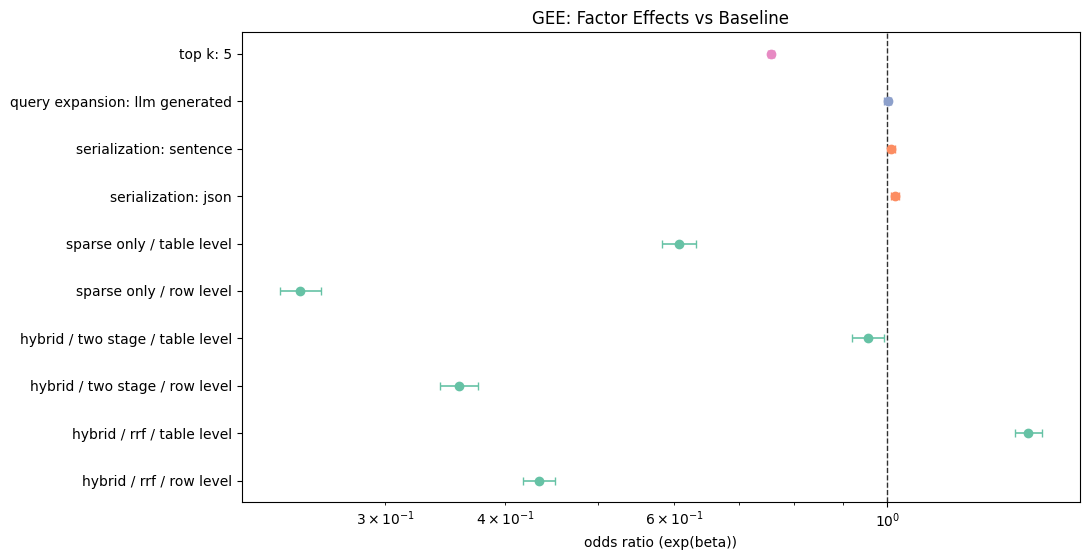

In [23]:

gee_effects_df = gee_effects_table(gee_result)
display(gee_effects_df)

fig, ax = plot_hit_gee_forest(gee_result, baseline_references, title='GEE: Factor Effects vs Baseline')
if fig is not None:
    plt.show()

## SPLADE vs BM25: каскадное сравнение только по hit@k

Сценарий фиксированный и последовательный:
0. `serialization = markdown`
1. `query_expansion = llm_generated`
2. `+ top_k = 10`
3. `+ chunking = table_level`

Метрика: только `hit@k`.

Визуализация выполняется через `seaborn`, с доверительными интервалами для каждого этапа и каждой модели (BM25/SPLADE).

rows total: 4628760
model_family distribution:


,rows
model_family,
BM25,2777256
SPLADE,1851504


,metric,stage_idx,stage_name,model_family,n,mean,ci_low,ci_high,ci_method
0,hit@k,1,markdown,BM25,925752,0.234252,0.233390,0.235115,beta_jeffreys
1,hit@k,1,markdown,SPLADE,617168,0.356264,0.355070,0.357460,beta_jeffreys
2,hit@k,2,llm_generated,BM25,674040,0.234554,0.233544,0.235567,beta_jeffreys
3,hit@k,2,llm_generated,SPLADE,449360,0.353587,0.352190,0.354986,beta_jeffreys
4,hit@k,3,top_k=10,BM25,337020,0.255213,0.253744,0.256687,beta_jeffreys
5,hit@k,3,top_k=10,SPLADE,224680,0.386483,0.384471,0.388498,beta_jeffreys
6,hit@k,4,chunking=table_level,BM25,112340,0.482206,0.479284,0.485128,beta_jeffreys
7,hit@k,4,chunking=table_level,SPLADE,112340,0.471951,0.469033,0.474871,beta_jeffreys


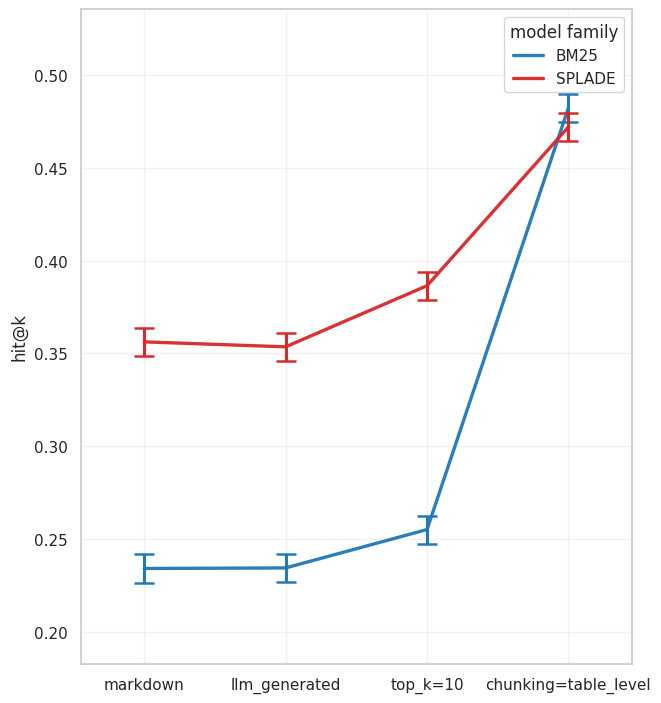

In [8]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DETAIL_PATHS_SPARSE_COMPARE = [
    'review_outputs/qdrant_retrieval_detail_20260328_192829.csv',
    'review_outputs/qdrant_retrieval_detail_20260329_080222.csv',
    'review_outputs/qdrant_retrieval_detail_20260329_090215.csv',
    'review_outputs/qdrant_retrieval_detail_20260421_083454.csv',
    'review_outputs/qdrant_retrieval_detail_20260421_072026.csv',
    'review_outputs/qdrant_retrieval_detail_20260420_203609.csv',
]

HIT_METRIC = 'hit@k'

# Визуальные настройки CI (не меняют статистику, только отображение).
CI_VIS_SCALE_Y = 2.6
MIN_CI_HALF_FRAC = 0.03

MANUAL_MODEL_BY_COLLECTION = {
    'intfloat_multilingual-e5-large-instruct_custom': 'BM25',
    'intfloat_multilingual-e5-large-instruct_naver_neuclir22-splade-ru_custom': 'SPLADE',
    'Qwen_Qwen3-Embedding-4B_Qdrant_bm25_custom': 'BM25',
    'Qwen_Qwen3-Embedding-4B_Qdrant_bm25_fetaqa': 'BM25',
}
MANUAL_MODEL_BY_FILE = {
    # 'qdrant_retrieval_detail_20260328_192829.csv': 'BM25',
    # 'qdrant_retrieval_detail_20260329_080222.csv': 'SPLADE',
}


def _infer_model_family(row: pd.Series) -> str:
    file_name = str(row.get('source_file', '')).strip()
    collection = str(row.get('collection', '')).strip()

    if collection in MANUAL_MODEL_BY_COLLECTION:
        return MANUAL_MODEL_BY_COLLECTION[collection]
    if file_name in MANUAL_MODEL_BY_FILE:
        return MANUAL_MODEL_BY_FILE[file_name]

    probe = ' | '.join([
        str(row.get('collection', '')),
        str(row.get('corpus_vector_names', '')),
        str(row.get('query_vector_names', '')),
        str(row.get('prefetch_using_vector_names_str', '')),
    ]).lower()

    if re.search(r'\bbm25\b|qdrant_bm25|bm-25', probe):
        return 'BM25'
    if re.search(r'splade|neuclir|naver', probe):
        return 'SPLADE'
    return 'UNKNOWN'


def _apply_stage_filters(df: pd.DataFrame):
    out = []
    current = df.copy()

    current = current[current['serialization'].astype(str) == 'markdown'].copy()
    out.append(('markdown', current.copy()))

    current = current[current['query_expansion'].astype(str) == 'llm_generated'].copy()
    out.append(('llm_generated', current.copy()))

    top_k_num = pd.to_numeric(current['top_k'], errors='coerce')
    current = current[top_k_num == 10].copy()
    out.append(('top_k=10', current.copy()))

    current = current[current['chunking'].astype(str) == 'table_level'].copy()
    out.append(('chunking=table_level', current.copy()))

    return out


def build_hit_stage_comparison(df: pd.DataFrame) -> pd.DataFrame:
    work = df.copy()
    work[HIT_METRIC] = pd.to_numeric(work[HIT_METRIC], errors='coerce')
    work = work[np.isfinite(work[HIT_METRIC])].copy()
    work = work[work['model_family'].isin(['BM25', 'SPLADE'])].copy()

    hit_model = globals().get('METRIC_CI_MODELS', {}).get('hit@k')
    if hit_model is None:
        hit_model = HitBetaCIModel(alpha=0.05) if 'HitBetaCIModel' in globals() else BootstrapCIModel(alpha=0.05, bootstrap_samples=1500)

    rows = []
    rng = np.random.default_rng(42)
    for stage_idx, (stage_name, stage_df) in enumerate(_apply_stage_filters(work), start=1):
        for family in ['BM25', 'SPLADE']:
            sub = stage_df[stage_df['model_family'] == family].copy()
            arr = pd.to_numeric(sub[HIT_METRIC], errors='coerce').to_numpy(dtype=float)
            arr = arr[np.isfinite(arr)]
            if arr.size == 0:
                mean, lo, hi, ci_method = np.nan, np.nan, np.nan, 'empty'
            else:
                mean, lo, hi, ci_method = hit_model.estimate(
                    n=int(arr.size),
                    sum_v=float(arr.sum()),
                    sumsq_v=float(np.square(arr).sum()),
                    samples=arr.tolist(),
                    rng=rng,
                )
            rows.append({
                'metric': HIT_METRIC,
                'stage_idx': stage_idx,
                'stage_name': stage_name,
                'model_family': family,
                'n': int(len(sub)),
                'mean': float(mean) if np.isfinite(mean) else np.nan,
                'ci_low': float(lo) if np.isfinite(lo) else np.nan,
                'ci_high': float(hi) if np.isfinite(hi) else np.nan,
                'ci_method': ci_method,
            })

    return pd.DataFrame(rows)


def plot_hit_stage_comparison_seaborn(stage_df: pd.DataFrame):
    if stage_df.empty:
        print('[INFO] Нет данных для hit@k')
        return

    stage_labels = [
        'markdown',
        'llm_generated',
        'top_k=10',
        'chunking=table_level',
    ]
    color_map = {'BM25': '#1f77b4', 'SPLADE': '#d62728'}

    p = stage_df.copy()
    p['stage_name'] = pd.Categorical(p['stage_name'], categories=stage_labels, ordered=True)
    p['x_base'] = p['stage_name'].cat.codes.astype(float)
    p = p.sort_values(['x_base', 'model_family']).reset_index(drop=True)

    y_low = float(np.nanmin(p['ci_low'])) if p['ci_low'].notna().any() else 0.0
    y_high = float(np.nanmax(p['ci_high'])) if p['ci_high'].notna().any() else 1.0
    y_span = max(y_high - y_low, 0.05)
    y_pad = max(0.02, y_span * 0.20)
    min_half = y_span * MIN_CI_HALF_FRAC

    sns.set_theme(style='whitegrid')
    fig, ax = plt.subplots(figsize=(6.8, 7.2))

    for family in ['BM25', 'SPLADE']:
        part = p[p['model_family'] == family].copy()
        if part.empty:
            continue

        ax.plot(
            part['x_base'],
            part['mean'],
            color=color_map[family],
            linewidth=2.4,
            alpha=0.95,
            label=family,
            zorder=2,
        )

        for _, r in part.iterrows():
            if not np.isfinite(r['mean']):
                continue
            y = float(r['mean'])
            raw_low = max(0.0, y - float(r['ci_low'])) if np.isfinite(r['ci_low']) else 0.0
            raw_high = max(0.0, float(r['ci_high']) - y) if np.isfinite(r['ci_high']) else 0.0

            # Искусственно усиливаем видимость CI по вертикали.
            vis_low = max(raw_low * CI_VIS_SCALE_Y, min_half)
            vis_high = max(raw_high * CI_VIS_SCALE_Y, min_half)
            vis_low = min(vis_low, y)
            vis_high = min(vis_high, 1.0 - y)

            ax.errorbar(
                x=float(r['x_base']),
                y=y,
                yerr=np.array([[vis_low], [vis_high]]),
                fmt='none',
                ecolor=color_map[family],
                elinewidth=2.2,
                capsize=7,
                capthick=1.8,
                alpha=0.98,
                zorder=4,
            )

    ax.set_ylabel('hit@k')
    ax.set_ylim(max(0.0, y_low - y_pad), min(1.0, y_high + y_pad))
    ax.set_xlim(-0.45, len(stage_labels) - 0.55)
    ax.set_xticks(range(len(stage_labels)))
    ax.set_xticklabels(stage_labels, rotation=0)
    ax.grid(alpha=0.25)
    ax.legend(title='model family', loc='best')
    plt.tight_layout()
    plt.show()


detail_compare_paths = [Path(p) for p in DETAIL_PATHS_SPARSE_COMPARE if Path(p).exists()]
if not detail_compare_paths:
    raise ValueError('Не найдены detail CSV для сравнения SPLADE/BM25')

need_cols = [
    'collection',
    'corpus_vector_names',
    'query_vector_names',
    'prefetch_using_vector_names_str',
    'serialization',
    'query_expansion',
    'top_k',
    'chunking',
    HIT_METRIC,
]

frames = []
for p in detail_compare_paths:
    d = pd.read_csv(p, usecols=lambda c: c in set(need_cols), low_memory=True)
    d['source_file'] = p.name
    frames.append(d)

cmp_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=need_cols + ['source_file'])
cmp_df['model_family'] = cmp_df.apply(_infer_model_family, axis=1)

print('rows total:', len(cmp_df))
print('model_family distribution:')
display(cmp_df['model_family'].value_counts(dropna=False).rename_axis('model_family').to_frame('rows'))

if not ({'BM25', 'SPLADE'} <= set(cmp_df['model_family'].astype(str))):
    print('[WARN] Не найдены одновременно BM25 и SPLADE. При необходимости дополните MANUAL_MODEL_BY_COLLECTION/MANUAL_MODEL_BY_FILE.')

hit_stage_df = build_hit_stage_comparison(cmp_df)
display(hit_stage_df)
plot_hit_stage_comparison_seaborn(hit_stage_df)

In [9]:
# Baseline: только метрики + доверительные интервалы (без визуализаций)
from pathlib import Path

import numpy as np
import pandas as pd

BASELINE_DETAIL_PATHS = [
    'review_outputs/qdrant_retrieval_baseline_detail_20260420_203236.csv',
]

BASELINE_METRICS = list(globals().get('METRICS', ['hit@k', 'mrr@k', 'recall_support_rows@k']))
METRIC_CI_MODELS_LOCAL = globals().get('METRIC_CI_MODELS', {})
RNG = np.random.default_rng(42)

if '_new_metric_state' not in globals() or '_update_metric_state' not in globals():
    raise ValueError('Сначала выполните ячейки с BootstrapCIModel/_new_metric_state/_update_metric_state')

if 'BootstrapCIModel' not in globals():
    raise ValueError('Сначала выполните ячейку с классом BootstrapCIModel')

# Добавляем дефолтные модели CI только для отсутствующих метрик.
for _m in BASELINE_METRICS:
    if _m not in METRIC_CI_MODELS_LOCAL:
        if _m == 'hit@k' and 'HitBetaCIModel' in globals():
            METRIC_CI_MODELS_LOCAL[_m] = HitBetaCIModel(alpha=0.05)
        else:
            METRIC_CI_MODELS_LOCAL[_m] = BootstrapCIModel(alpha=0.05, bootstrap_samples=1500)

states = {_m: _new_metric_state() for _m in BASELINE_METRICS}

for _path in BASELINE_DETAIL_PATHS:
    p = Path(_path)
    if not p.exists():
        print(f'[WARN] file not found: {p}')
        continue

    print(f'[INFO] Reading baseline detail: {p}')
    for chunk in pd.read_csv(
        p,
        usecols=lambda c: c in set(BASELINE_METRICS),
        chunksize=250_000,
        low_memory=True,
    ):
        for metric in BASELINE_METRICS:
            if metric not in chunk.columns:
                continue
            vals = pd.to_numeric(chunk[metric], errors='coerce').to_numpy(dtype=float)
            vals = vals[np.isfinite(vals)]
            _update_metric_state(states[metric], vals, rng=RNG, reservoir_size=2000)

rows = []
for metric in BASELINE_METRICS:
    st = states[metric]
    n = int(st['n'])
    if n <= 0:
        rows.append({
            'metric': metric,
            'n': 0,
            'mean': np.nan,
            'ci_low': np.nan,
            'ci_high': np.nan,
            'ci_method': 'empty',
        })
        continue

    model = METRIC_CI_MODELS_LOCAL[metric]
    mean, lo, hi, ci_method = model.estimate(
        n=n,
        sum_v=float(st['sum_v']),
        sumsq_v=float(st['sumsq_v']),
        samples=list(st['samples']),
        rng=RNG,
    )
    rows.append({
        'metric': metric,
        'n': n,
        'mean': float(mean),
        'ci_low': float(lo),
        'ci_high': float(hi),
        'ci_method': ci_method,
    })

baseline_ci_df = pd.DataFrame(rows).sort_values('metric').reset_index(drop=True)
display(baseline_ci_df)

[INFO] Reading baseline detail: review_outputs/qdrant_retrieval_baseline_detail_20260420_203236.csv


,metric,n,mean,ci_low,ci_high,ci_method
0,hit@k,10488,0.521644,0.512079,0.531197,beta_jeffreys
1,mrr@k,10488,0.342623,0.324638,0.360740,bootstrap
2,recall_support_rows@k,10488,0.510567,0.490039,0.531485,bootstrap


In [9]:
# Таблица оценок по конфигурациям: bm25 / splade / hybrid с разбиением на rrf и two_stage
from pathlib import Path
import re

import numpy as np
import pandas as pd

CONFIG_LABELS_ORDER = [
    'bm25',
    'splade',
    'hybrid (splade, rrf)',
    'hybrid (splade, two_stage)',
    'hybrid (bm25, rrf)',
    'hybrid (bm25, two_stage)',
]
CONFIG_METRICS = list(globals().get('METRICS', ['hit@k', 'mrr@k', 'recall_support_rows@k']))
CONFIG_CI_MODELS = globals().get('METRIC_CI_MODELS', {}).copy()
RNG_CFG = np.random.default_rng(42)

if '_new_metric_state' not in globals() or '_update_metric_state' not in globals():
    raise ValueError('Сначала выполните ячейки с BootstrapCIModel/_new_metric_state/_update_metric_state')

if 'BootstrapCIModel' not in globals():
    raise ValueError('Сначала выполните ячейку с классом BootstrapCIModel')

for _m in CONFIG_METRICS:
    if _m not in CONFIG_CI_MODELS:
        if _m == 'hit@k' and 'HitBetaCIModel' in globals():
            CONFIG_CI_MODELS[_m] = HitBetaCIModel(alpha=0.05)
        else:
            CONFIG_CI_MODELS[_m] = BootstrapCIModel(alpha=0.05, bootstrap_samples=1500)

CONFIG_DETAIL_PATHS = [
    'review_outputs/qdrant_retrieval_detail_20260328_192829.csv',
    'review_outputs/qdrant_retrieval_detail_20260329_080222.csv',
    'review_outputs/qdrant_retrieval_detail_20260329_090215.csv',
    'review_outputs/qdrant_retrieval_detail_20260421_083454.csv',
    'review_outputs/qdrant_retrieval_detail_20260421_072026.csv',
    'review_outputs/qdrant_retrieval_detail_20260420_203609.csv',
]

CONFIG_NEED_COLS = [
    'collection',
    'corpus_vector_names',
    'query_vector_names',
    'prefetch_using_vector_names_str',
    'retrieval_strategy',
    *CONFIG_METRICS,
]

def _is_hybrid_by_prefetch(v) -> bool:
    txt = str(v).strip().lower()
    if '|' in txt:
        return True
    return False

def _probe_text(row: pd.Series) -> str:
    return ' | '.join([
        str(row.get('collection', '')),
        str(row.get('corpus_vector_names', '')),
        str(row.get('query_vector_names', '')),
        str(row.get('prefetch_using_vector_names_str', '')),
        str(row.get('retrieval_strategy', '')),
    ]).lower()

def _infer_family_local(row: pd.Series) -> str:
    if '_infer_model_family' in globals():
        try:
            fam = str(_infer_model_family(row)).upper()
            if fam in {'BM25', 'SPLADE'}:
                return fam
        except Exception:
            pass
    probe = _probe_text(row)
    if re.search(r'\bbm25\b|qdrant_bm25|bm-25', probe):
        return 'BM25'
    if re.search(r'splade|neuclir|naver', probe):
        return 'SPLADE'
    return 'UNKNOWN'

def _infer_hybrid_mode(row: pd.Series) -> str:
    strategy = str(row.get('retrieval_strategy', '')).strip().lower()
    probe = _probe_text(row)

    # Для строк, где встречаются оба маркера, считаем что two_stage приоритетнее.
    if 'two_stage' in strategy or 'two-stage' in strategy or 'two_stage' in probe or 'two-stage' in probe:
        return 'two_stage'
    if 'rrf' in strategy or 'rrf' in probe:
        return 'rrf'
    return 'unknown'

def _infer_config_label(row: pd.Series) -> str:
    family = _infer_family_local(row)
    strategy = str(row.get('retrieval_strategy', '')).strip().lower()
    is_hybrid = ('hybrid' in strategy) or _is_hybrid_by_prefetch(row.get('prefetch_using_vector_names_str', ''))

    if is_hybrid:
        mode = _infer_hybrid_mode(row)
        if mode not in {'rrf', 'two_stage'}:
            return 'unknown'
        if family == 'SPLADE':
            return f'hybrid (splade, {mode})'
        if family == 'BM25':
            return f'hybrid (bm25, {mode})'
        return 'unknown'

    if family == 'SPLADE':
        return 'splade'
    if family == 'BM25':
        return 'bm25'
    return 'unknown'

states = {(cfg, m): _new_metric_state() for cfg in CONFIG_LABELS_ORDER for m in CONFIG_METRICS}

for _path in CONFIG_DETAIL_PATHS:
    p = Path(_path)
    if not p.exists():
        print(f'[WARN] file not found: {p}')
        continue

    print(f'[INFO] Reading config detail: {p}')
    for chunk in pd.read_csv(
        p,
        usecols=lambda c: c in set(CONFIG_NEED_COLS),
        chunksize=250_000,
        low_memory=True,
    ):
        chunk = chunk.copy()
        chunk['config_label'] = chunk.apply(_infer_config_label, axis=1)
        chunk = chunk[chunk['config_label'].isin(CONFIG_LABELS_ORDER)].copy()
        if chunk.empty:
            continue

        for cfg, sub in chunk.groupby('config_label', dropna=False, observed=True):
            for metric in CONFIG_METRICS:
                if metric not in sub.columns:
                    continue
                vals = pd.to_numeric(sub[metric], errors='coerce').to_numpy(dtype=float)
                vals = vals[np.isfinite(vals)]
                _update_metric_state(states[(cfg, metric)], vals, rng=RNG_CFG, reservoir_size=2000)

rows = []
for cfg in CONFIG_LABELS_ORDER:
    for metric in CONFIG_METRICS:
        st = states[(cfg, metric)]
        n = int(st['n'])
        if n <= 0:
            rows.append({
                'config': cfg,
                'metric': metric,
                'n': 0,
                'mean': np.nan,
                'ci_low': np.nan,
                'ci_high': np.nan,
                'ci_method': 'empty',
            })
            continue

        model = CONFIG_CI_MODELS[metric]
        mean, lo, hi, ci_method = model.estimate(
            n=n,
            sum_v=float(st['sum_v']),
            sumsq_v=float(st['sumsq_v']),
            samples=list(st['samples']),
            rng=RNG_CFG,
        )
        rows.append({
            'config': cfg,
            'metric': metric,
            'n': n,
            'mean': float(mean),
            'ci_low': float(lo),
            'ci_high': float(hi),
            'ci_method': ci_method,
        })

config_metrics_df = pd.DataFrame(rows)
config_metrics_df['config'] = pd.Categorical(
    config_metrics_df['config'], categories=CONFIG_LABELS_ORDER, ordered=True
)
config_metrics_df = config_metrics_df.sort_values(['config', 'metric']).reset_index(drop=True)

display(config_metrics_df)

[INFO] Reading config detail: review_outputs/qdrant_retrieval_detail_20260328_192829.csv
[INFO] Reading config detail: review_outputs/qdrant_retrieval_detail_20260329_080222.csv
[INFO] Reading config detail: review_outputs/qdrant_retrieval_detail_20260329_090215.csv
[INFO] Reading config detail: review_outputs/qdrant_retrieval_detail_20260421_083454.csv
[INFO] Reading config detail: review_outputs/qdrant_retrieval_detail_20260421_072026.csv
[INFO] Reading config detail: review_outputs/qdrant_retrieval_detail_20260420_203609.csv


,config,metric,n,mean,ci_low,ci_high,ci_method
0,bm25,hit@k,1388628,0.224106,0.223413,0.224800,beta_jeffreys
1,bm25,mrr@k,1388628,0.156409,0.142594,0.171909,bootstrap
2,bm25,recall_support_rows@k,1388628,0.201815,0.185184,0.218596,bootstrap
3,splade,hit@k,925752,0.353908,0.352934,0.354882,beta_jeffreys
4,splade,mrr@k,925752,0.230658,0.214806,0.247582,bootstrap
5,splade,recall_support_rows@k,925752,0.312496,0.292572,0.331830,bootstrap
6,"hybrid (splade, rrf)",hit@k,462876,0.400304,0.398893,0.401716,beta_jeffreys
7,"hybrid (splade, rrf)",mrr@k,462876,0.252562,0.235583,0.269812,bootstrap
8,"hybrid (splade, rrf)",recall_support_rows@k,462876,0.347511,0.327086,0.366168,bootstrap
9,"hybrid (splade, two_stage)",hit@k,462876,0.389104,0.387700,0.390509,beta_jeffreys


In [ ]:
from pathlib import Path
import re

import numpy as np
import pandas as pd

# Таблица: сериализация × чанкование для hybrid (bm25, rrf)
SER_CHUNK_SERIALIZATION_ORDER = ['markdown'] # 'json', 'markdown', 'sentence'
SER_CHUNK_CHUNKING_ORDER = ['row_level', 'table_level', ] # 'schema_cell'
SER_CHUNK_METRICS = list(globals().get('METRICS', ['hit@k', 'mrr@k', 'recall_support_rows@k']))
SER_CHUNK_CI_MODELS = globals().get('METRIC_CI_MODELS', {}).copy()
RNG_SER_CHUNK = np.random.default_rng(42)

# Дополнительная фиксация параметров эксперимента
SER_CHUNK_FIXED_QUERY_EXPANSION = 'none' # llm_generated
SER_CHUNK_FIXED_TOP_K = 10

if '_new_metric_state' not in globals() or '_update_metric_state' not in globals():
    raise ValueError('Сначала выполните ячейки с BootstrapCIModel/_new_metric_state/_update_metric_state')

if 'BootstrapCIModel' not in globals():
    raise ValueError('Сначала выполните ячейку с классом BootstrapCIModel')

for _m in SER_CHUNK_METRICS:
    if _m not in SER_CHUNK_CI_MODELS:
        if _m == 'hit@k' and 'HitBetaCIModel' in globals():
            SER_CHUNK_CI_MODELS[_m] = HitBetaCIModel(alpha=0.05)
        else:
            SER_CHUNK_CI_MODELS[_m] = BootstrapCIModel(alpha=0.05, bootstrap_samples=1500)

SER_CHUNK_DETAIL_PATHS = [
    # 'review_outputs/qdrant_retrieval_detail_20260429_074422.csv',
    # 'review_outputs/qdrant_retrieval_detail_20260429_090748.csv',
    # 'review_outputs/qdrant_retrieval_detail_20260429_133525.csv',
    # 'review_outputs/qdrant_retrieval_detail_20260506_223015.csv'
    'review_outputs/qdrant_retrieval_detail_20260507_180308.csv'
]

SER_CHUNK_NEED_COLS = [
    'collection',
    'corpus_vector_names',
    'query_vector_names',
    'prefetch_using_vector_names_str',
    'retrieval_strategy',
    'serialization',
    'chunking',
    'query_expansion',
    'top_k',
    *SER_CHUNK_METRICS,
]

def _is_hybrid_bm25_rrf(row: pd.Series) -> bool:
    """Проверяем что это hybrid (bm25, rrf) + фиксированные query_expansion/top_k."""
    family = _infer_family_local(row)
    print(family)
    if family != 'BM25':
        return False

    query_expansion = str(row.get('query_expansion', '')).strip().lower()
    if query_expansion != SER_CHUNK_FIXED_QUERY_EXPANSION:
        return False

    top_k = pd.to_numeric(row.get('top_k', np.nan), errors='coerce')
    if not np.isfinite(top_k) or int(top_k) != SER_CHUNK_FIXED_TOP_K:
        return False

    strategy = str(row.get('retrieval_strategy', '')).strip().lower()
    is_hybrid = _is_hybrid_by_prefetch(row.get('prefetch_using_vector_names_str', ''))

    if not is_hybrid:
        return False

    # Проверяем что это rrf (не two_stage)
    if 'rrf' in strategy:
        return True

    return False

# Состояния для каждой комбинации (serialization, chunking, metric)
states_ser_chunk = {
    (ser, chunk, m): _new_metric_state()
    for ser in SER_CHUNK_SERIALIZATION_ORDER
    for chunk in SER_CHUNK_CHUNKING_ORDER
    for m in SER_CHUNK_METRICS
}

for _path in SER_CHUNK_DETAIL_PATHS:
    p = Path(_path)
    if not p.exists():
        print(f'[WARN] file not found: {p}')
        continue

    print(f'[INFO] Reading serialization/chunking detail: {p}')
    for chunk_data in pd.read_csv(
        p,
        usecols=lambda c: c in set(SER_CHUNK_NEED_COLS),
        chunksize=250_000,
        low_memory=True,
    ):
        chunk_data = chunk_data.copy()

        # Ранний фильтр по фиксированным параметрам
        chunk_data['query_expansion'] = chunk_data['query_expansion'].astype(str).str.strip().str.lower()
        top_k_num = pd.to_numeric(chunk_data['top_k'], errors='coerce')
        chunk_data = chunk_data[
            (chunk_data['query_expansion'] == SER_CHUNK_FIXED_QUERY_EXPANSION)
            & (np.isfinite(top_k_num))
            & (top_k_num.astype(int) == SER_CHUNK_FIXED_TOP_K)
        ].copy()
        if chunk_data.empty:
            continue

        # Фильтруем только hybrid (bm25, rrf)
        chunk_data = chunk_data[chunk_data.apply(_is_hybrid_bm25_rrf, axis=1)].copy()
        if chunk_data.empty:
            continue

        # Нормализуем значения сериализации и чанкования
        chunk_data['serialization'] = chunk_data['serialization'].astype(str).str.strip().str.lower()
        chunk_data['chunking'] = chunk_data['chunking'].astype(str).str.strip().str.lower()

        # Фильтруем известные значения
        chunk_data = chunk_data[chunk_data['serialization'].isin(SER_CHUNK_SERIALIZATION_ORDER)].copy()
        chunk_data = chunk_data[chunk_data['chunking'].isin(SER_CHUNK_CHUNKING_ORDER)].copy()

        if chunk_data.empty:
            continue

        for (ser, chunk_val), sub in chunk_data.groupby(['serialization', 'chunking'], dropna=False, observed=True):
            for metric in SER_CHUNK_METRICS:
                if metric not in sub.columns:
                    continue
                vals = pd.to_numeric(sub[metric], errors='coerce').to_numpy(dtype=float)
                vals = vals[np.isfinite(vals)]
                _update_metric_state(states_ser_chunk[(ser, chunk_val, metric)], vals, rng=RNG_SER_CHUNK, reservoir_size=2000)

# Строим итоговую таблицу
rows_ser_chunk = []
for ser in SER_CHUNK_SERIALIZATION_ORDER:
    for chunk_val in SER_CHUNK_CHUNKING_ORDER:
        for metric in SER_CHUNK_METRICS:
            st = states_ser_chunk[(ser, chunk_val, metric)]
            n = int(st['n'])
            if n <= 0:
                rows_ser_chunk.append({
                    'serialization': ser,
                    'chunking': chunk_val,
                    'metric': metric,
                    'n': 0,
                    'mean': np.nan,
                    'ci_low': np.nan,
                    'ci_high': np.nan,
                    'ci_method': 'empty',
                })
                continue

            model = SER_CHUNK_CI_MODELS[metric]
            mean, lo, hi, ci_method = model.estimate(
                n=n,
                sum_v=float(st['sum_v']),
                sumsq_v=float(st['sumsq_v']),
                samples=list(st['samples']),
                rng=RNG_SER_CHUNK,
            )
            rows_ser_chunk.append({
                'serialization': ser,
                'chunking': chunk_val,
                'metric': metric,
                'n': n,
                'mean': float(mean),
                'ci_low': float(lo),
                'ci_high': float(hi),
                'ci_method': ci_method,
            })

ser_chunk_metrics_df = pd.DataFrame(rows_ser_chunk)
ser_chunk_metrics_df['serialization'] = pd.Categorical(
    ser_chunk_metrics_df['serialization'], categories=SER_CHUNK_SERIALIZATION_ORDER, ordered=True
)
ser_chunk_metrics_df['chunking'] = pd.Categorical(
    ser_chunk_metrics_df['chunking'], categories=SER_CHUNK_CHUNKING_ORDER, ordered=True
)
ser_chunk_metrics_df = ser_chunk_metrics_df.sort_values(['serialization', 'chunking', 'metric']).reset_index(drop=True)

display(ser_chunk_metrics_df)